<a href="https://colab.research.google.com/github/IssarapongB/Data-science/blob/main/99424_LAB_ACTIVITY3_DAY2_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("Ready for Reinforcement Learning Lab 3: Weighted FrozenLake")


Ready for Reinforcement Learning Lab 3: Weighted FrozenLake


In [ ]:
N     = 5   					#  เปลี่ยนตามโจทย์
START = 0   					# เปลี่ยนตามโจทย์
GOAL  = 4   					# เปลี่ยนตามโจทย์
reward_map = np.array([          		# เปลี่ยนตามโจทย์
    [ 0,   0,  -5,  1,  20],  # Row 0
    [ 0, -10,   1,  1, -10],  # Row 1
    [ 0,   0, -10,  0,   2],  # Row 2
    [-10,  1,   1,  0,   0],  # Row 3
    [ 0,   0,  -5,  1, -10],  # Row 4
])
HOLES = {2, 6, 9, 12, 15, 22, 24}  		# เปลี่ยนตามโจทย์
ACTIONS = {0:"Left", 1:"Down", 2:"Right", 3:"Up"}

print("Grid size:", N, "x", N)
print("Start:", START)
print("Goal:", GOAL)
print("Holes:", HOLES)
print("Reward map:")
print(reward_map)


Grid size: 5 x 5
Start: 0
Goal: 4
Holes: {2, 6, 22, 24, 9, 12, 15}
Reward map:
[[  0   0  -5   1  20]
 [  0 -10   1   1 -10]
 [  0   0 -10   0   2]
 [-10   1   1   0   0]
 [  0   0  -5   1 -10]]


In [ ]:
def to_rc(state):
    row = state // N   # หารเอาส่วน = แถว
    col = state % N    # หารเอาเศษ = คอลัมน์
    return row, col

def to_state(row, col):
    state = row * N + col
    return state

def move(state, action):
    row, col = to_rc(state)
    if action == 0:   col = max(0, col - 1)      		# ซ้าย
    elif action == 1: row = min(N-1, row + 1)  		# ลง
    elif action == 2: col = min(N-1, col + 1)  		# ขวา
    elif action == 3: row = max(0, row - 1)      	# ขึ้น
    return to_state(row, col)


In [ ]:
# def step_env(state, action):
#     new_state = move(state, action)
#     row, col = to_rc(new_state)
#     reward = reward_map[row, col]

#     step_penalty = -1.2
#     reward = reward + step_penalty

#     if new_state == GOAL:
#         done = True
#     elif new_state in HOLES:
#         done = True
#     else:
#         done = False
#     return new_state, reward, done

# def step_env(state, action):
#     new_state = move(state, action)
#     if new_state in HOLES:
#         reward = -1
#         done = True
#     elif new_state == GOAL:
#         reward = 1
#         done = True
#     else:
#         # --- ปรับแต่งจากเดิมที่เป็น 0 ให้ติดลบเล็กน้อย เพื่อบีบให้ Agent อยากจบเกมไว ๆ ---
#         reward = -0.01
#         done = False
#     return new_state, reward, done


# def step_env(state, action):
#     new_state = move(state, action)
#     row, col = to_rc(new_state)
#     reward = reward_map[row, col]

#     # ปรับลดความรุนแรงลง เพื่อไม่ให้คะแนนดิ่งติดลบเร็วเกินไป
#     step_penalty = -0.02
#     reward = reward + step_penalty

#     if new_state == GOAL:
#         done = True
#     elif new_state in HOLES:
#         done = True
#     else:
#         done = False
#     return new_state, reward, done

def step_env(state, action):
    new_state = move(state, action)
    row, col = to_rc(new_state)
    reward = reward_map[row, col]

    step_penalty = -2
    reward = reward + step_penalty

    if new_state == GOAL:
        done = True
    elif new_state in HOLES:
        done = True
    else:
        done = False
        # --- ปรับเพิ่ม: ถ้า Agent เลือกเดินแล้วผลลัพธ์ย่ำอยู่ที่เดิม ให้ทำโทษแต้มติดลบเพิ่ม ---
        if new_state == state:
            reward = reward - 5

    return new_state, reward, done


In [ ]:
state = 0
action = 2

new_state, reward, done = step_env(state, action)

print("Old state:", state)
print("Action:", ACTIONS[action])
print("New state:", new_state)
print("Reward:", reward)
print("Done:", done)


Old state: 0
Action: Right
New state: 1
Reward: -2
Done: False


In [ ]:
def plot_reward_map(title="Weighted FrozenLake 5x5"):
    fig, ax = plt.subplots(figsize=(6, 6))
    for r in range(N):
        for c in range(N):
            state = to_state(r, c)
            value = reward_map[r, c]

            if state == START:
                facecolor = "#d7ecff"
                label = f"S\nState {state}\nReward {value}"
            elif state == GOAL:
                facecolor = "#d8f5d0"
                label = f"G\nState {state}\nReward +{value}"
            elif state in HOLES:
                facecolor = "#ffd6d6"
                label = f"H\nState {state}\nReward {value}"
            elif value > 0:
                facecolor = "#fff4c2"
                label = f"State {state}\nReward +{value}"
            else:
                facecolor = "#f7f7f7"
                label = f"State {state}\nReward {value}"

            rect = patches.Rectangle(
                (c, r),
                1,
                1,
                facecolor=facecolor,
                edgecolor="black",
                linewidth=1.5
            )
            ax.add_patch(rect)
            ax.text(
                c + 0.5,
                r + 0.5,
                label,
                ha="center",
                va="center",
                fontsize=9
            )

    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.show()



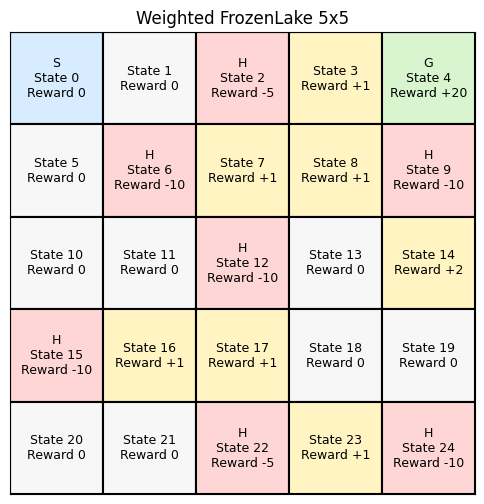

In [ ]:
plot_reward_map()

In [ ]:
n_states = N * N
n_actions = 4
Q = np.zeros((n_states, n_actions))

print("Q-table shape:", Q.shape)
print(Q)


Q-table shape: (25, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [ ]:
def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        action = np.random.randint(0, n_actions)
    else:
    # หาค่า Q สูงสุดของ State ปัจจุบัน
        max_value = np.max(Q[state])

# หา Action ทุกตัวที่มีค่า Q เท่ากับค่าสูงสุด
        best_actions = np.where(Q[state] == max_value)[0]

# สุ่มเลือก 1 Action จากกลุ่ม Action ที่ดีที่สุด
# เพื่อไม่ให้ np.argmax เลือก Action แรกเสมอ
        action = np.random.choice(best_actions)
    return action


In [ ]:
# alpha = 0.1
# gamma = 0.95
# epsilon = 1.0
# epsilon_min = 0.05
# epsilon_decay = 0.995
# episodes = 5000
# max_steps = 100
# success_flags = []
# total_rewards = []

alpha = 0.1
gamma = 0.95

# --- ส่วนที่แนะนำให้ปรับแก้ไข ---
epsilon = 1.0

epsilon_min = 0.05

epsilon_decay = 0.999   # <--- ปรับจาก 0.995 เป็น 0.998
episodes = 10000         # <--- ปรับจาก 5000 เป็น 8000 หรือ 10000 รอบ
max_steps = 2000         # <--- ปรับจาก 100 เป็น 150 หรือ 200 ก้าว
# --------------------------------

success_flags = []
total_rewards = []


In [ ]:
for ep in range(episodes):
    state = START
    total_reward = 0
    win = 0

    for step in range(max_steps):
        action = choose_action(state, epsilon)
        new_state, reward, done = step_env(state, action)
        old_value = Q[state, action]
        if done:
          next_max = 0
        else:
          next_max = np.max(Q[new_state])
        new_value = old_value + alpha * (reward + gamma * next_max - old_value)
        Q[state, action] = new_value
        total_reward += reward
        state = new_state

        if done:
            if state == GOAL:
                win = 1
            break

    success_flags.append(win)
    total_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
print("Training finished")
print("Final epsilon:", epsilon)
print("Success rate:", np.mean(success_flags) * 100)
print("Average reward:", np.mean(total_rewards))


Training finished
Final epsilon: 0.05
Success rate: 36.26
Average reward: -6.961


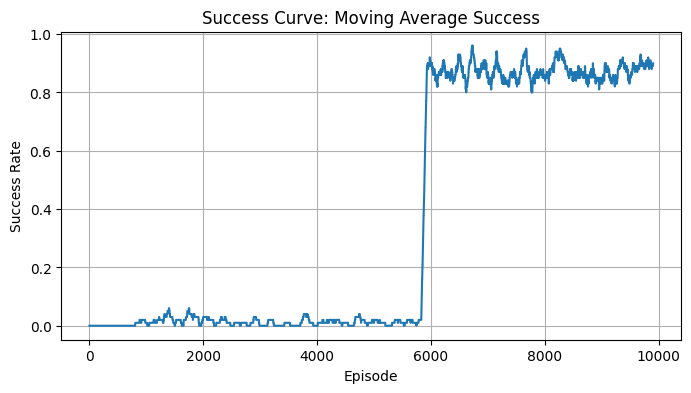

In [ ]:
window = 100

success_moving = np.convolve(success_flags, np.ones(window)/window, mode="valid")
plt.figure(figsize=(8, 4))
plt.plot(success_moving)
plt.title("Success Curve: Moving Average Success")
plt.xlabel("Episode")
plt.ylabel("Success Rate")
plt.grid(True)
plt.show()



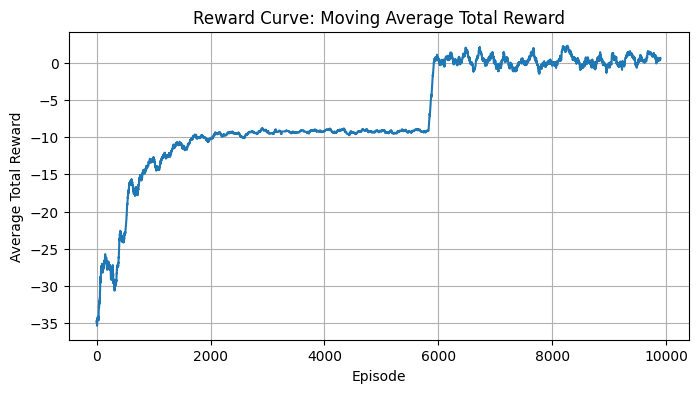

In [ ]:
reward_moving = np.convolve(total_rewards, np.ones(window)/window, mode="valid")

plt.figure(figsize=(8, 4))
plt.plot(reward_moving)
plt.title("Reward Curve: Moving Average Total Reward")
plt.xlabel("Episode")
plt.ylabel("Average Total Reward")
plt.grid(True)
plt.show()


In [ ]:
arrow = {0: "←", 1: "↓", 2: "→", 3: "↑"}

for state in range(n_states):
    best_action = np.argmax(Q[state])
    print(f"State {state:2d}: Q={np.round(Q[state], 2)} Best={arrow[best_action]}")


State  0: Q=[-7.53 -0.41 -8.65 -7.4 ] Best=↓
State  1: Q=[ -9.43 -12.    -7.   -13.65] Best=→
State  2: Q=[0. 0. 0. 0.] Best=←
State  3: Q=[-6.9  14.22 18.   11.  ] Best=→
State  4: Q=[0. 0. 0. 0.] Best=←
State  5: Q=[ -5.49   1.67 -12.    -2.4 ] Best=↓
State  6: Q=[0. 0. 0. 0.] Best=←
State  7: Q=[-2.28 -2.28 14.14 -0.7 ] Best=→
State  8: Q=[ 11.74  11.55 -11.9   16.1 ] Best=↑
State  9: Q=[0. 0. 0. 0.] Best=←
State 10: Q=[ -3.38 -12.     3.86  -0.43] Best=→
State 11: Q=[  1.59   6.17 -12.   -12.  ] Best=↓
State 12: Q=[0. 0. 0. 0.] Best=←
State 13: Q=[-11.96   8.92  10.68  14.29] Best=↑
State 14: Q=[11.58 -2.2   0.07 -5.62] Best=←
State 15: Q=[0. 0. 0. 0.] Best=←
State 16: Q=[-12.     2.72   7.55   3.69] Best=→
State 17: Q=[  6.12  -7.     9.   -11.98] Best=→
State 18: Q=[ 7.29  7.22  6.79 11.58] Best=↑
State 19: Q=[-1.53 -5.62 -3.43 10.59] Best=↑
State 20: Q=[-5.08 -4.71 -3.86 -4.91] Best=→
State 21: Q=[-4.72 -4.89 -5.22  5.91] Best=↑
State 22: Q=[0. 0. 0. 0.] Best=←
State 23: Q=[-2.8

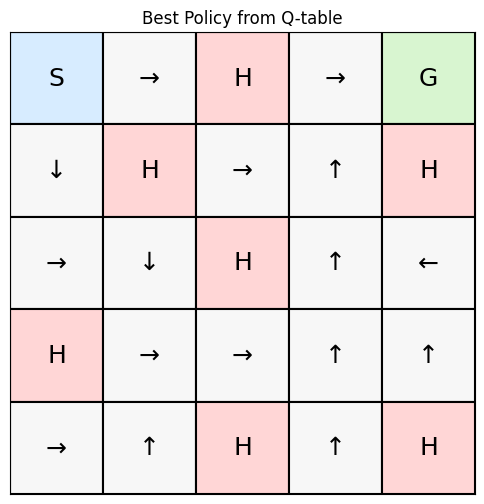

In [ ]:
def plot_policy(title="Best Policy from Q-table"):
    fig, ax = plt.subplots(figsize=(6, 6))

    for r in range(N):
        for c in range(N):
            state = to_state(r, c)
            if state == START:
                facecolor = "#d7ecff"
                label = "S"
            elif state == GOAL:
                facecolor = "#d8f5d0"
                label = "G"
            elif state in HOLES:
                facecolor = "#ffd6d6"
                label = "H"

            else:
                facecolor = "#f7f7f7"
                best_action = np.argmax(Q[state])
                label = arrow[best_action]

            rect = patches.Rectangle(
                (c, r),
                1,
                1,
                facecolor=facecolor,
                edgecolor="black",
                linewidth=1.5
            )
            ax.add_patch(rect)

            ax.text(
                c + 0.5,
                r + 0.5,
                label,
                ha="center",
                va="center",
                fontsize=18
            )

    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.show()

plot_policy()


Best path: [0, 5, 10, 11, 16, 17, 18, 13, 8, 3, 4]
Total reward: 4
Result: Success - Agent reached the Goal


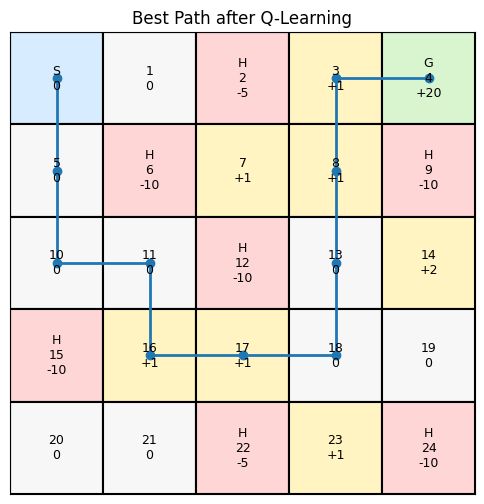

In [ ]:
def plot_path(path, title="Best Path after Q-Learning"):
    fig, ax = plt.subplots(figsize=(6, 6))

    for r in range(N):
        for c in range(N):
            state = to_state(r, c)
            value = reward_map[r, c]

            if state == START:
                facecolor = "#d7ecff"
                label = f"S\n{state}"
            elif state == GOAL:
                facecolor = "#d8f5d0"
                label = f"G\n{state}\n+{value}"
            elif state in HOLES:
                facecolor = "#ffd6d6"
                label = f"H\n{state}\n{value}"
            elif value > 0:
                facecolor = "#fff4c2"
                label = f"{state}\n+{value}"
            else:
                facecolor = "#f7f7f7"
                label = f"{state}\n{value}"

            rect = patches.Rectangle(
                (c, r),
                1,
                1,
                facecolor=facecolor,
                edgecolor="black",
                linewidth=1.5
            )
            ax.add_patch(rect)

            ax.text(
                c + 0.5,
                r + 0.5,
                label,
                ha="center",
                va="center",
                fontsize=9
            )

    xs = []
    ys = []

    for s in path:
        r, c = to_rc(s)
        xs.append(c + 0.5)
        ys.append(r + 0.5)

    ax.plot(xs, ys, marker="o", linewidth=2)
    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.show()
state = START
path = [state]
total_reward = 0
visited = {state}

for step in range(30):
    action = np.argmax(Q[state])
    max_value = np.max(Q[state])
    best_actions = np.where(Q[state] == max_value)[0]
    action = np.random.choice(best_actions)

    new_state, reward, done = step_env(state, action)
    path.append(new_state)
    total_reward += reward

    if new_state in visited and not done:
        print("Detected loop at state:", new_state)
        state = new_state
        break

    visited.add(new_state)
    state = new_state

    if done:
        break

print("Best path:", path)
print("Total reward:", total_reward)

if state == GOAL:
    print("Result: Success - Agent reached the Goal")
elif state in HOLES:
    print("Result: Failed - Agent fell into a Hole")
else:
    print("Result: Timeout - Agent did not reach terminal state")

plot_path(path, title="Best Path after Q-Learning")